In [9]:
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.randn(5, 3), columns=['A', 'B', 'C'])

df.head()

,A,B,C
0,0.637903,1.903772,-0.551755
1,-0.274833,-0.791319,0.603255
2,0.093627,1.575203,0.207490
3,0.415045,-0.452059,-1.409863
4,-0.512395,-0.070816,0.503313


{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


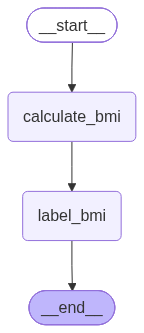

In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)


# compile the graph
workflow = graph.compile()
# execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)
{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [2]:
"""
LangGraph Practice: Sequential + Parallel + Conditional + Loop
----------------------------------------------------------------
A single graph, no LLM/API key needed. Pure Python logic so you
can focus on graph structure, not prompt engineering.

Flow:
  start -> add_five -> multiply_two
        -> (parallel) square_node + cube_node -> join
        -> (conditional) even_node / odd_node
        -> (loop) countdown_node (loops on itself) -> END
"""

import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END


# 1. Define the shared state -------------------------------------------------
# Note: "log" uses Annotated + operator.add so that when two nodes (the
# parallel branches) write to it in the same step, LangGraph *merges*
# (concatenates) the lists instead of raising a conflict error.
class State(TypedDict):
    value: int
    square: int
    cube: int
    counter: int
    log: Annotated[list[str], operator.add]


# 2. SEQUENTIAL nodes ----------------------------------------------------
# These only ever run one-at-a-time, so returning a partial dict is safe.
def start_node(state: State) -> dict:
    return {"log": [f"start: value={state['value']}"]}

def add_five(state: State) -> dict:
    new_value = state["value"] + 5
    return {"value": new_value, "log": [f"add_five: value={new_value}"]}

def multiply_two(state: State) -> dict:
    new_value = state["value"] * 2
    return {"value": new_value, "log": [f"multiply_two: value={new_value}"]}


# 3. PARALLEL nodes (both run off multiply_two, then converge at join) ----
# IMPORTANT: each branch only returns the key(s) IT owns ("square" or
# "cube"), never "value" — if both branches wrote "value" in the same
# step, LangGraph wouldn't know which write should win and would error.
def square_node(state: State) -> dict:
    sq = state["value"] ** 2
    return {"square": sq, "log": [f"square_node: square={sq}"]}

def cube_node(state: State) -> dict:
    cb = state["value"] ** 3
    return {"cube": cb, "log": [f"cube_node: cube={cb}"]}

def join_node(state: State) -> dict:
    return {"log": ["join_node: merged parallel branches"]}


# 4. CONDITIONAL routing ---------------------------------------------------
def route_even_odd(state: State) -> str:
    return "even_node" if state["value"] % 2 == 0 else "odd_node"

def even_node(state: State) -> dict:
    return {"counter": 3, "log": ["even_node: value is even"]}

def odd_node(state: State) -> dict:
    return {"counter": 4, "log": ["odd_node: value is odd"]}


# 5. LOOP node (keeps calling itself until counter hits 0) ----------------
def countdown_node(state: State) -> dict:
    new_counter = state["counter"] - 1
    return {"counter": new_counter, "log": [f"countdown_node: counter={new_counter}"]}

def should_continue_loop(state: State) -> str:
    return "loop" if state["counter"] > 0 else "done"


# 6. Build the graph -------------------------------------------------------
graph = StateGraph(State)

graph.add_node("start_node", start_node)
graph.add_node("add_five", add_five)
graph.add_node("multiply_two", multiply_two)
graph.add_node("square_node", square_node)
graph.add_node("cube_node", cube_node)
graph.add_node("join_node", join_node)
graph.add_node("even_node", even_node)
graph.add_node("odd_node", odd_node)
graph.add_node("countdown_node", countdown_node)

# Sequential edges
graph.add_edge(START, "start_node")
graph.add_edge("start_node", "add_five")
graph.add_edge("add_five", "multiply_two")

# Parallel fan-out then fan-in
graph.add_edge("multiply_two", "square_node")
graph.add_edge("multiply_two", "cube_node")
graph.add_edge("square_node", "join_node")
graph.add_edge("cube_node", "join_node")

# Conditional branch
graph.add_conditional_edges(
    "join_node",
    route_even_odd,
    {"even_node": "even_node", "odd_node": "odd_node"},
)

# Both branches feed into the loop
graph.add_edge("even_node", "countdown_node")
graph.add_edge("odd_node", "countdown_node")

# Loop: countdown_node keeps calling itself until counter == 0
graph.add_conditional_edges(
    "countdown_node",
    should_continue_loop,
    {"loop": "countdown_node", "done": END},
)

app = graph.compile()


# 7. Run it ------------------------------------------------------------------
if __name__ == "__main__":
    result = app.invoke({"value": 3, "square": 0, "cube": 0, "counter": 0, "log": []})

    print("\n--- Execution log ---")
    for line in result["log"]:
        print(line)

    print("\n--- Final state ---")
    print(result)


--- Execution log ---
start: value=3
add_five: value=8
multiply_two: value=16
cube_node: cube=4096
square_node: square=256
join_node: merged parallel branches
even_node: value is even
countdown_node: counter=2
countdown_node: counter=1
countdown_node: counter=0

--- Final state ---
{'value': 16, 'square': 256, 'cube': 4096, 'counter': 0, 'log': ['start: value=3', 'add_five: value=8', 'multiply_two: value=16', 'cube_node: cube=4096', 'square_node: square=256', 'join_node: merged parallel branches', 'even_node: value is even', 'countdown_node: counter=2', 'countdown_node: counter=1', 'countdown_node: counter=0']}


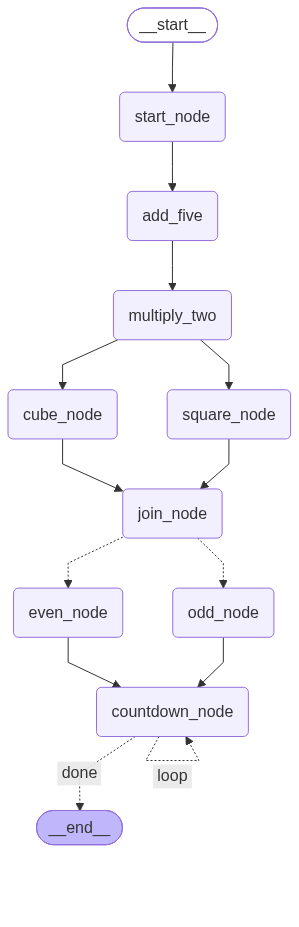

In [4]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())